In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

# 列名
column_names = ['Status_of_existing_checking_account', 'Duration_in_month',
                'Credit_history', 'Purpose', 'Credit_amount', 'Savings_account',
                'Employment_since', 'Installment_rate', 'Personal_status',
                'Other_debtors', 'Residence_since', 'Property', 'Age',
                'Other_installment_plans', 'Housing', 'Existing_credits',
                'Job', 'Liable_people', 'Telephone', 'Foreign_worker', 'Credit_risk']

df = pd.read_csv(url, sep=' ', header=None, names=column_names)

print(f"Data Amount: {len(df)}")
print(df.head())
print(f"\nCredit Distribution:")
print(df['Credit_risk'].value_counts())

Data Amount: 1000
  Status_of_existing_checking_account  Duration_in_month Credit_history  \
0                                 A11                  6            A34   
1                                 A12                 48            A32   
2                                 A14                 12            A34   
3                                 A11                 42            A32   
4                                 A11                 24            A33   

  Purpose  Credit_amount Savings_account Employment_since  Installment_rate  \
0     A43           1169             A65              A75                 4   
1     A43           5951             A61              A73                 2   
2     A46           2096             A61              A74                 2   
3     A42           7882             A61              A74                 2   
4     A40           4870             A61              A73                 3   

  Personal_status Other_debtors  ...  Property Age  Othe

In [3]:
df['Default'] = (df['Credit_risk']==2).astype(int)
print("Credit Distribution: ")
print(df['Default'].value_counts())
print(f"\nDefault Percentage: {df['Default'].mean():.2%}")

Credit Distribution: 
Default
0    700
1    300
Name: count, dtype: int64

Default Percentage: 30.00%


In [4]:
# Delete the previous Credit_risk column
df = df.drop('Credit_risk', axis=1)

# Check Data Type
print(f"\nData Type：")
print(df.dtypes)


Data Type：
Status_of_existing_checking_account    object
Duration_in_month                       int64
Credit_history                         object
Purpose                                object
Credit_amount                           int64
Savings_account                        object
Employment_since                       object
Installment_rate                        int64
Personal_status                        object
Other_debtors                          object
Residence_since                         int64
Property                               object
Age                                     int64
Other_installment_plans                object
Housing                                object
Existing_credits                        int64
Job                                    object
Liable_people                           int64
Telephone                              object
Foreign_worker                         object
Default                                 int64
dtype: object


In [5]:
# Find all Object
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Transvert to Numbers
for col in categorical_cols:
    df[col] = pd.factorize(df[col])[0]

# Check
print("\nNew Data Tyoe：")
print(df.dtypes)


New Data Tyoe：
Status_of_existing_checking_account    int64
Duration_in_month                      int64
Credit_history                         int64
Purpose                                int64
Credit_amount                          int64
Savings_account                        int64
Employment_since                       int64
Installment_rate                       int64
Personal_status                        int64
Other_debtors                          int64
Residence_since                        int64
Property                               int64
Age                                    int64
Other_installment_plans                int64
Housing                                int64
Existing_credits                       int64
Job                                    int64
Liable_people                          int64
Telephone                              int64
Foreign_worker                         int64
Default                                int64
dtype: object


In [6]:
from sklearn.model_selection import train_test_split

# 分离特征和目标变量
X = df.drop('Default', axis=1)  # 所有特征（用来预测）
y = df['Default']                # 目标变量（违约了没）

print(f"X 的形状: {X.shape}")      # 应该是 (1000, 20)
print(f"y 的形状: {y.shape}")      # 应该是 (1000,)

# 分割数据：80%训练，20%测试
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20%作为测试集
    random_state=42,         # 固定随机种子（保证可重复）
    stratify=y               # 保证训练集和测试集的违约率比例相同
)

print(f"\n训练集大小: {X_train.shape[0]} 行")
print(f"测试集大小: {X_test.shape[0]} 行")

print(f"\n训练集违约率: {y_train.mean():.2%}")
print(f"测试集违约率: {y_test.mean():.2%}")

X 的形状: (1000, 20)
y 的形状: (1000,)

训练集大小: 800 行
测试集大小: 200 行

训练集违约率: 30.00%
测试集违约率: 30.00%


In [7]:
from sklearn.preprocessing import StandardScaler

# 创建标准化工具
scaler = StandardScaler()

# 用训练数据学习怎么标准化
X_train_scaled = scaler.fit_transform(X_train)

# 用同样的方式标准化测试数据
X_test_scaled = scaler.transform(X_test)

print("标准化完成！")

# 验证一下
print(f"\n标准化前 - Credit_amount 的范围:")
print(f"  最小值: {X_train['Credit_amount'].min()}")
print(f"  最大值: {X_train['Credit_amount'].max()}")
print(f"  平均值: {X_train['Credit_amount'].mean():.2f}")

print(f"\n标准化后 - Credit_amount 的范围:")
print(f"  最小值: {X_train_scaled[:, 4].min():.2f}")  # Credit_amount 是第5列
print(f"  最大值: {X_train_scaled[:, 4].max():.2f}")
print(f"  平均值: {X_train_scaled[:, 4].mean():.2f}")

标准化完成！

标准化前 - Credit_amount 的范围:
  最小值: 276
  最大值: 15945
  平均值: 3189.59

标准化后 - Credit_amount 的范围:
  最小值: -1.09
  最大值: 4.77
  平均值: 0.00


In [8]:
from sklearn.linear_model import LogisticRegression

# 创建模型
model = LogisticRegression(max_iter=1000, random_state=42)

# 用训练数据训练
model.fit(X_train_scaled, y_train)

print("✓ 模型训练完成！")

# 看看模型学到了什么
print("\n每个特征的系数（权重）：")
print("="*50)

feature_names = X_train.columns
for name, coef in zip(feature_names, model.coef_[0]):
    if coef > 0:
        direction = "↑ 增加违约风险"
    else:
        direction = "↓ 降低违约风险"
    print(f"{name:40s}: {coef:7.4f}  {direction}")

✓ 模型训练完成！

每个特征的系数（权重）：
Status_of_existing_checking_account     : -0.6474  ↓ 降低违约风险
Duration_in_month                       :  0.2601  ↑ 增加违约风险
Credit_history                          :  0.3023  ↑ 增加违约风险
Purpose                                 : -0.0292  ↓ 降低违约风险
Credit_amount                           :  0.1799  ↑ 增加违约风险
Savings_account                         :  0.0300  ↑ 增加违约风险
Employment_since                        :  0.2320  ↑ 增加违约风险
Installment_rate                        :  0.2697  ↑ 增加违约风险
Personal_status                         :  0.2012  ↑ 增加违约风险
Other_debtors                           :  0.0619  ↑ 增加违约风险
Residence_since                         : -0.0458  ↓ 降低违约风险
Property                                :  0.1691  ↑ 增加违约风险
Age                                     :  0.0230  ↑ 增加违约风险
Other_installment_plans                 :  0.1719  ↑ 增加违约风险
Housing                                 :  0.2407  ↑ 增加违约风险
Existing_credits                        :  0.0105  ↑ 增加违约风险
Job             

In [9]:
# 用模型预测测试集的违约概率
y_pred_proba = model.predict_proba(X_test_scaled)

print("预测结果的形状：", y_pred_proba.shape)
print("\n前10个样本的预测结果：")
print(y_pred_proba[:10])

# 提取违约概率（第二列）
y_pred_proba_1 = y_pred_proba[:, 1]

print("\n前10个样本的违约概率：")
print(y_pred_proba_1[:10])

print(f"\n违约概率的范围：")
print(f"  最小: {y_pred_proba_1.min():.4f}")
print(f"  最大: {y_pred_proba_1.max():.4f}")
print(f"  平均: {y_pred_proba_1.mean():.4f}")

预测结果的形状： (200, 2)

前10个样本的预测结果：
[[0.63400361 0.36599639]
 [0.78995847 0.21004153]
 [0.1768454  0.8231546 ]
 [0.49416235 0.50583765]
 [0.75234133 0.24765867]
 [0.76747546 0.23252454]
 [0.88678185 0.11321815]
 [0.65069999 0.34930001]
 [0.61573912 0.38426088]
 [0.76431376 0.23568624]]

前10个样本的违约概率：
[0.36599639 0.21004153 0.8231546  0.50583765 0.24765867 0.23252454
 0.11321815 0.34930001 0.38426088 0.23568624]

违约概率的范围：
  最小: 0.0244
  最大: 0.9094
  平均: 0.3091


In [10]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 计算 AUC
auc = roc_auc_score(y_test, y_pred_proba_1)

print(f"AUC 得分: {auc:.4f}")
print()

# AUC 的解释
if auc >= 0.9:
    print("✓✓✓ 非常好！模型表现优秀")
elif auc >= 0.8:
    print("✓✓ 很好！模型表现良好")
elif auc >= 0.7:
    print("✓ 还不错，模型表现可以")
elif auc >= 0.6:
    print("△ 一般，模型表现一般")
else:
    print("✗ 差，模型表现不好")

AUC 得分: 0.7748

✓ 还不错，模型表现可以


In [12]:
from sklearn.metrics import roc_curve

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

# KS = tpr - fpr 的最大值
ks_stat = max(tpr - fpr)

# 找到最优的阈值（KS最大的点）
best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]

print(f"KS 值: {ks_stat:.4f}")
print(f"最优阈值: {best_threshold:.4f}")
print()

# KS 的解释
if ks_stat >= 0.4:
    print("✓✓✓ 非常好！模型区分能力很强")
elif ks_stat >= 0.3:
    print("✓✓ 很好！模型区分能力强")
elif ks_stat >= 0.2:
    print("✓ 还不错，模型区分能力一般")
else:
    print("✗ 差，模型区分能力弱")

KS 值: 0.4833
最优阈值: 0.2917

✓✓✓ 非常好！模型区分能力很强


/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 21028 (\N{CJK UNIFIED IDEOGRAPH-5224}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/413253875.py:31: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from

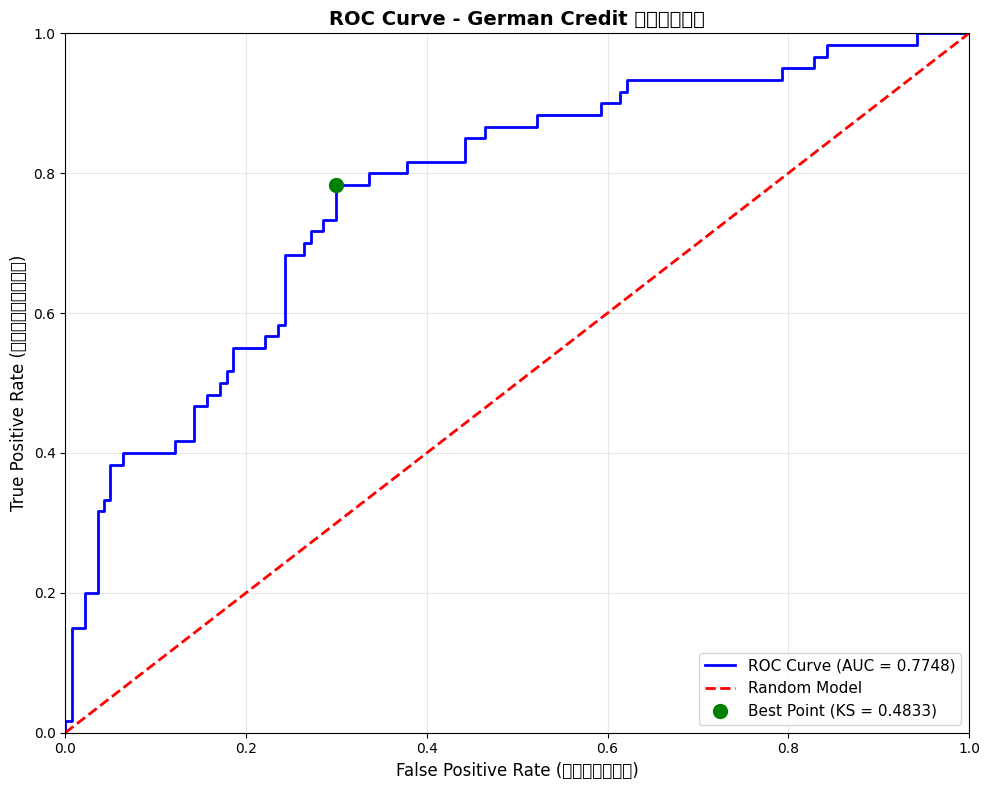

✓ ROC 曲线已显示


In [13]:
import matplotlib.pyplot as plt

# 创建图表
plt.figure(figsize=(10, 8))

# 画 ROC 曲线
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')

# 画对角线（随机模型的参考线）
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Model')

# 标记最优点（KS最大的点）
plt.plot(fpr[best_idx], tpr[best_idx], 'go', markersize=10,
         label=f'Best Point (KS = {ks_stat:.4f})')

# 添加标签和标题
plt.xlabel('False Positive Rate (误判好人的比例)', fontsize=12)
plt.ylabel('True Positive Rate (正确识别坏人的比例)', fontsize=12)
plt.title('ROC Curve - German Credit 违约预测模型', fontsize=14, fontweight='bold')

# 添加网格
plt.grid(True, alpha=0.3)

# 添加图例
plt.legend(fontsize=11, loc='lower right')

# 设置坐标轴范围
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print("✓ ROC 曲线已显示")

In [14]:
import numpy as np

# 方法：线性转换
# 违约概率 0 → 分数 850（最安全）
# 违约概率 1 → 分数 300（最危险）

def probability_to_score(proba):
    """把违约概率转成分数"""
    min_score = 300
    max_score = 850
    # 反向映射：概率越高，分数越低
    score = max_score - (proba * (max_score - min_score))
    return score

# 转换所有测试数据
scores = probability_to_score(y_pred_proba_1)

print("分数统计：")
print(f"  最低分: {scores.min():.0f}")
print(f"  最高分: {scores.max():.0f}")
print(f"  平均分: {scores.mean():.0f}")
print(f"  中位数: {np.median(scores):.0f}")

print(f"\n前20个样本的分数：")
for i in range(20):
    print(f"  样本{i+1:2d}: 违约概率={y_pred_proba_1[i]:.4f} → 分数={scores[i]:.0f}")

分数统计：
  最低分: 350
  最高分: 837
  平均分: 680
  中位数: 711

前20个样本的分数：
  样本 1: 违约概率=0.3660 → 分数=649
  样本 2: 违约概率=0.2100 → 分数=734
  样本 3: 违约概率=0.8232 → 分数=397
  样本 4: 违约概率=0.5058 → 分数=572
  样本 5: 违约概率=0.2477 → 分数=714
  样本 6: 违约概率=0.2325 → 分数=722
  样本 7: 违约概率=0.1132 → 分数=788
  样本 8: 违约概率=0.3493 → 分数=658
  样本 9: 违约概率=0.3843 → 分数=639
  样本10: 违约概率=0.2357 → 分数=720
  样本11: 违约概率=0.2082 → 分数=735
  样本12: 违约概率=0.3294 → 分数=669
  样本13: 违约概率=0.0706 → 分数=811
  样本14: 违约概率=0.2236 → 分数=727
  样本15: 违约概率=0.4647 → 分数=594
  样本16: 违约概率=0.0620 → 分数=816
  样本17: 违约概率=0.2083 → 分数=735
  样本18: 违约概率=0.1432 → 分数=771
  样本19: 违约概率=0.2502 → 分数=712
  样本20: 违约概率=0.1162 → 分数=786


In [15]:
import pandas as pd

# 创建分级规则
# A级（最好）→ E级（最差）

bins = [0, 500, 600, 700, 800, 1000]
labels = ['E', 'D', 'C', 'B', 'A']

# 分级
grades = pd.cut(scores, bins=bins, labels=labels, include_lowest=True)

# 创建分析表
analysis_df = pd.DataFrame({
    'score': scores,
    'grade': grades,
    'actual_default': y_test.values
})

# 按等级分组统计
grade_stats = analysis_df.groupby('grade').agg({
    'score': ['min', 'max', 'count'],
    'actual_default': ['sum', 'mean']
}).round(4)

# 重新命名列
grade_stats.columns = ['最低分', '最高分', '人数', '违约人数', '违约率']

print("\n" + "="*70)
print("评分卡分析")
print("="*70)
print(grade_stats)
print()

# 验证：违约率是否随等级下降而上升？
print("✓ 验证：各等级的违约率")
for grade in ['A', 'B', 'C', 'D', 'E']:
    rate = grade_stats.loc[grade, '违约率']
    print(f"  {grade}级: {rate:.2%}")


评分卡分析
            最低分       最高分  人数  违约人数     违约率
grade                                      
E      349.8348  497.6610  20    15  0.7500
D      506.4372  599.2127  28    13  0.4643
C      602.5353  691.7739  45    19  0.4222
B      704.4123  799.7032  82    11  0.1341
A      800.1757  836.5852  25     2  0.0800

✓ 验证：各等级的违约率
  A级: 8.00%
  B级: 13.41%
  C级: 42.22%
  D级: 46.43%
  E级: 75.00%


/tmp/ipykernel_781/1074426901.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_stats = analysis_df.groupby('grade').agg({


In [16]:
# 创建一个简单的决策规则
def make_decision(score):
    """根据分数做贷款决策"""
    if score >= 800:
        return 'A', '✓ 自动批准'
    elif score >= 700:
        return 'B', '✓ 标准批准'
    elif score >= 600:
        return 'C', '△ 严格审核'
    elif score >= 500:
        return 'D', '✗ 需经理审核'
    else:
        return 'E', '✗ 拒绝'

# 测试几个例子
print("贷款决策示例：")
print("="*60)

test_scores = [450, 550, 650, 750, 820]

for score in test_scores:
    grade, decision = make_decision(score)
    print(f"分数 {score}: {grade}级 → {decision}")

贷款决策示例：
分数 450: E级 → ✗ 拒绝
分数 550: D级 → ✗ 需经理审核
分数 650: C级 → △ 严格审核
分数 750: B级 → ✓ 标准批准
分数 820: A级 → ✓ 自动批准
